### Sprawozdanie: Analiza porównawcza danych rzeczywistych z wykorzystaniem metod statystyki opisowej


#### Opis zadania:

Zadanie polega na opracowaniu sprawozdania prezentującego analizę wybranego zbioru danych rzeczywistych z wykorzystaniem poznanych metod statystyki opisowej. Celem pracy jest nie tylko przedstawienie wyników analizy, ale również zrozumienie oraz interpretacja statystycznych własnści danych. Sprawozdanie powinno być przygotowane w sposób przejrzysty, z dbałością o poprawność merytoryczną i językową. Sprawozdanie należy przesłać pocztą elektroniczną w formacie .pdf - sam raport, bez kodów


1. **Wstęp** – należy krótko opisać zbiór danych (charakter danych, liczba obserwacji, itp.), wskazać jego źródło oraz określić cel analizy – co chcemy sprawdzić, opisać lub porównać.


2. **Analiza rozkładu przy pomocy metryk statystycznych** – należy obliczyć i omówić podstawowe poznane miary statystyczne, takie jak miary położenia, zmienności, kształtu rozkładu. Dla każdej z tych miar należy podać definicję, wzór oraz ich interpretację w kontekście analizowanych danych. Szczególny nacisk należy położyć na formułowanie wniosków z uzyskanych wyników.


Miary położenia:

- Średnia arytmetyczna
- Mediana
- Dominanta (moda)
- Kwartyle (np. Q1, Q2, Q3)
- Minimum i maksimum

Miary zmienności (rozproszenia):

- Rozstęp (max - min)
- Rozstęp międzykwartylowy (Q3 - Q1)
- Wariancja
- Odchylenie standardowe
- Współczynnik zmienności (czyli odchylenie standardowe / średnia)

Miary kształtu rozkładu:

- Skośność
- Kurtoza


In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as sts
from scipy.stats import kurtosis, skew

In [39]:
def stats(x):
    mean = np.mean(x)
    median = np.median(x)
    iqr = np.percentile(x, 75) - np.percentile(x, 25)
    variance = np.var(x)
    odchylenie = np.std(x)
    kurtoza = kurtosis(x)
    skosnosc = skew(x)

    return mean, median, iqr, variance, odchylenie, kurtoza, skosnosc

In [40]:
data = pd.read_csv("Guns.csv")

print(data.head())

   rownames  year  violent  murder  robbery  prisoners      afam      cauc  \
0         1  1977    414.4    14.2     96.8         83  8.384873  55.12291   
1         2  1978    419.1    13.3     99.1         94  8.352101  55.14367   
2         3  1979    413.3    13.2    109.5        144  8.329575  55.13586   
3         4  1980    448.5    13.2    132.1        141  8.408386  54.91259   
4         5  1981    470.5    11.9    126.5        149  8.483435  54.92513   

       male  population    income   density    state law  
0  18.17441    3.780403  9563.148  0.074552  Alabama  no  
1  17.99408    3.831838  9932.000  0.075567  Alabama  no  
2  17.83934    3.866248  9877.028  0.076245  Alabama  no  
3  17.73420    3.900368  9541.428  0.076829  Alabama  no  
4  17.67372    3.918531  9548.351  0.077187  Alabama  no  


In [41]:
dane1 = data[data["law"] == "yes"]["violent"]
dane2 = data[data["law"] == "no"]["violent"]

dane1, dane2

(41      770.9
 42      727.7
 43      701.1
 44      653.9
 45      631.5
         ...  
 1168    254.2
 1169    249.7
 1170    255.2
 1171    247.6
 1172    232.3
 Name: violent, Length: 285, dtype: float64,
 0       414.4
 1       419.1
 2       413.3
 3       448.5
 4       470.5
         ...  
 1163    301.4
 1164    310.2
 1165    319.5
 1166    286.2
 1167    272.5
 Name: violent, Length: 888, dtype: float64)

In [42]:
stats1 = stats(dane1)
stats2 = stats(dane2)
print(f"Statystyki dla danych z prawem: {stats1}")
print(f"średnia: {stats1[0]}")
print(f"mediana: {stats1[1]}")
print(f"rozstęp miedzykwartylowy: {stats1[2]}")
print(f"wariancja: {stats1[3]}")
print(f"odchylenie standardowe: {stats1[4]}")
print(f"kurtoza: {stats1[5]}")
print(f"skosnosc: {stats1[6]}")
print("\n")
print(f"Statystyki dla danych bez prawa: {stats2}")
print(f"średnia: {stats2[0]}")
print(f"mediana: {stats2[1]}")
print(f"rozstęp miedzykwartylowy: {stats2[2]}")
print(f"wariancja: {stats2[3]}")
print(f"odchylenie standardowe: {stats2[4]}")
print(f"kurtoza: {stats2[5]}")
print(f"skosnosc: {stats2[6]}")

Statystyki dla danych z prawem: (381.05087719298245, 322.0, 365.1, 70801.25821852878, 266.0850582398959, 0.8019592744432038, 1.1040057700500554)
średnia: 381.05087719298245
mediana: 322.0
rozstęp miedzykwartylowy: 365.1
wariancja: 70801.25821852878
odchylenie standardowe: 266.0850582398959
kurtoza: 0.8019592744432038
skosnosc: 1.1040057700500554


Statystyki dla danych bez prawa: (542.2377252252252, 478.4, 361.4, 118442.36169617675, 344.15456076620103, 12.765011426552599, 2.780385736103082)
średnia: 542.2377252252252
mediana: 478.4
rozstęp miedzykwartylowy: 361.4
wariancja: 118442.36169617675
odchylenie standardowe: 344.15456076620103
kurtoza: 12.765011426552599
skosnosc: 2.780385736103082


In [43]:
q1yes = np.percentile(dane1, 25)
q3yes = np.percentile(dane1, 75)
q1no = np.percentile(dane2, 25)
q3no = np.percentile(dane2, 75)

print(f"Q1 dla danych z prawem: {q1yes}")
print(f"Q3 dla danych z prawem: {q3yes}")
print(f"Q1 dla danych bez prawa: {q1no}")
print(f"Q3 dla danych bez prawa: {q3no}")

Q1 dla danych z prawem: 149.5
Q3 dla danych z prawem: 514.6
Q1 dla danych bez prawa: 315.0
Q3 dla danych bez prawa: 676.4


In [44]:
max1 = np.max(dane1)
min1 = np.min(dane1)
max2 = np.max(dane2)
min2 = np.min(dane2)
r1 = max1 - min1
r2 = max2 - min2

print("Rozstęp dla danych z prawem:", r1)
print("Rozstęp dla danych bez prawa:", r2)

Rozstęp dla danych z prawem: 1193.0
Rozstęp dla danych bez prawa: 2874.8


In [45]:
wspolczynnikzmiennosci1 = stats1[4] / stats1[0]
wspolczynnikzmiennosci2 = stats2[4] / stats2[0]
print("Współczynnik zmienności dla danych z prawem:", wspolczynnikzmiennosci1)
print("Współczynnik zmienności dla danych bez prawa:", wspolczynnikzmiennosci2)

Współczynnik zmienności dla danych z prawem: 0.6982927324561378
Współczynnik zmienności dla danych bez prawa: 0.6346931332069382


3. **Prezentacja rozkładów na wykresach** – należy przedstawić dane graficznie, wykorzystując różne typy wykresów omawiane na zajęciach. Każdy wykres powinien być poprawnie opisany oraz zinterpretowany. W tej części również oczekuje się wyciągania wniosków na podstawie obserwacji graficznych.


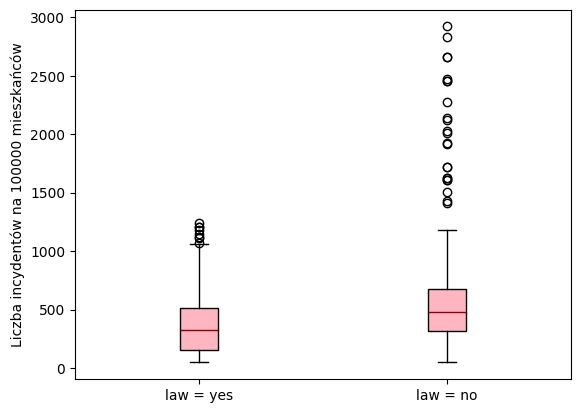

In [46]:
plt.boxplot(
    [dane1, dane2],
    labels=["law = yes", "law = no"],
    patch_artist=True,
    boxprops=dict(facecolor="lightpink"),
    medianprops=dict(color="darkred"),
)
plt.ylabel("Liczba incydentów na 100000 mieszkańców")
plt.show()

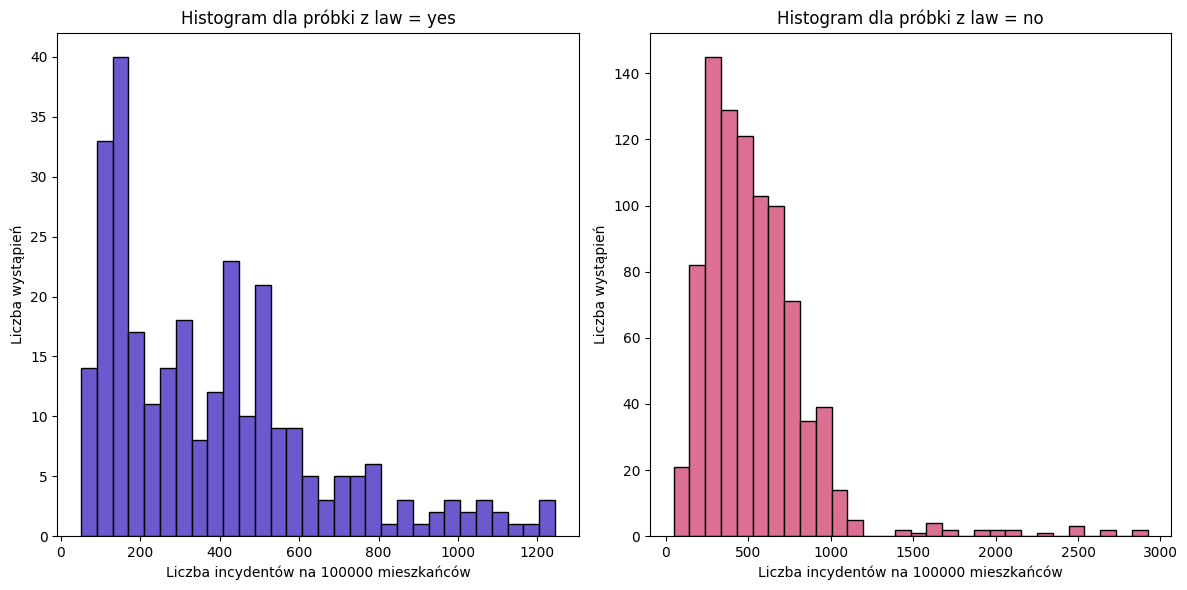

In [47]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.hist(dane1, bins=30, color="slateblue", edgecolor="black")
plt.xlabel("Liczba incydentów na 100000 mieszkańców")
plt.ylabel("Liczba wystąpień")
plt.title("Histogram dla próbki z law = yes")

plt.subplot(1, 2, 2)
plt.hist(dane2, bins=30, color="palevioletred", edgecolor="black")
plt.xlabel("Liczba incydentów na 100000 mieszkańców")
plt.ylabel("Liczba wystąpień")
plt.title("Histogram dla próbki z law = no")

plt.tight_layout()
plt.show()

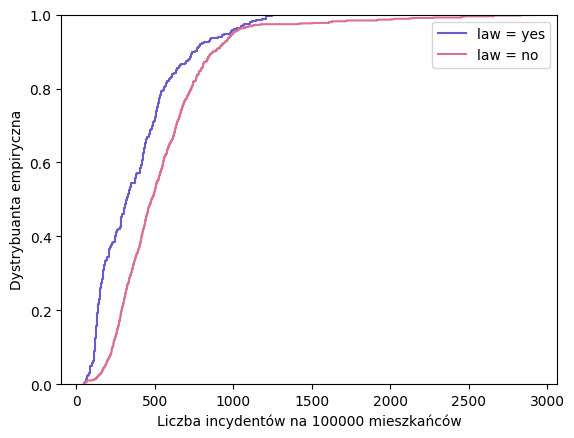

In [48]:
# plt.figure(figsize=(12, 6))
sns.ecdfplot(dane1, label="law = yes", color="slateblue")
plt.xlabel("Liczba incydentów na 100000 mieszkańców")
plt.ylabel("Dystrybuanta empiryczna")
sns.ecdfplot(dane2, label="law = no", color="palevioletred")
plt.legend()
plt.show()

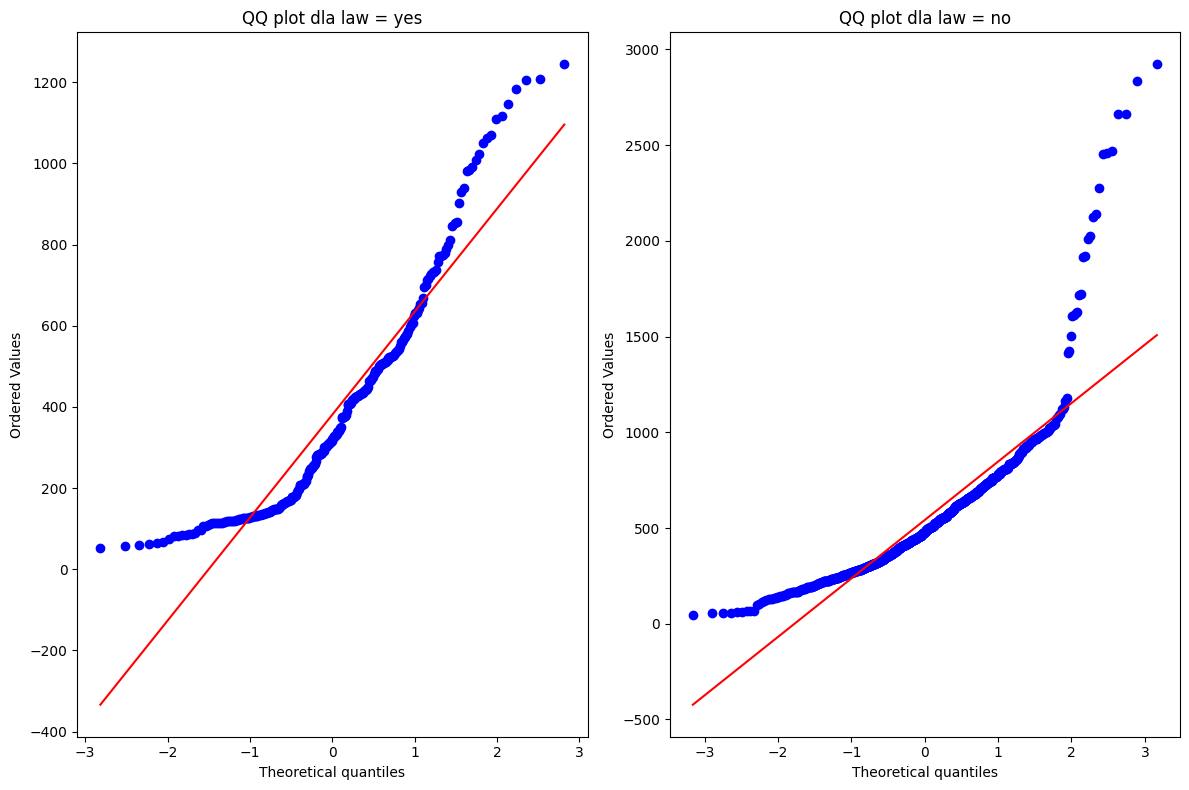

In [49]:
plt.figure(figsize=(12, 8))
plt.subplot(1, 2, 1)
sts.probplot(dane1, dist="norm", plot=plt)
plt.title("QQ plot dla law = yes")
plt.subplot(1, 2, 2)
sts.probplot(dane2, dist="norm", plot=plt)
plt.title("QQ plot dla law = no")
plt.tight_layout()

4. **Podsumowanie** – zwięzła synteza uzyskanych wyników i kluczowe wnioski płynące z analizy.
